## Are the Recon Files Good Enough ##

Comparing the recon fields to v202111 fields.  Are the monthly averages of key quantities similar to the particular year, given the range of values across years?

In [2]:
import cmocean.cm as cm
import copy
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from salishsea_tools import viz_tools

In [3]:
bathy = xr.open_dataset('/home/sallen/MEOPAR/grid/bathymetry_202108.nc')
mesh = xr.open_dataset('/home/sallen/MEOPAR/grid/mesh_mask202108.nc')

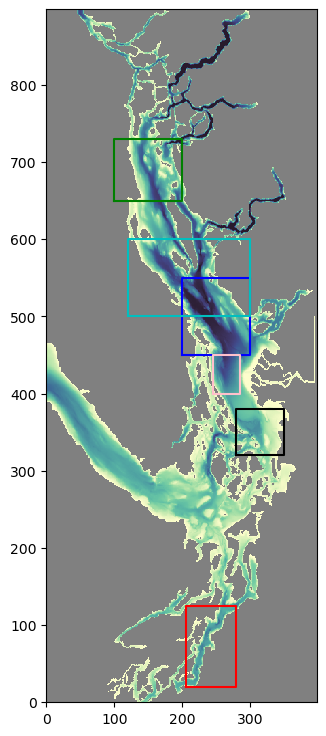

In [4]:
def plot_box(ax, corn, colour):
    ax.plot([corn[2], corn[3], corn[3], corn[2], corn[2]], 
            [corn[0], corn[0], corn[1], corn[1], corn[0]], '-', color=colour)
fig, ax = plt.subplots(1, 1, figsize=(5, 9))
mycmap = cm.deep
mycmap.set_bad('grey')
ax.pcolormesh(bathy['Bathymetry'], cmap=mycmap)
viz_tools.set_aspect(ax);
SoG_center = [450, 550, 200, 300]
plot_box(ax, SoG_center, 'b')
SoG_ncenter = [500, 600, 120, 300]
plot_box(ax, SoG_ncenter, 'c')
SoG_south = [320, 380, 280, 350]
plot_box(ax, SoG_south, 'k')
SoG_venus = [400, 450, 245, 285]
plot_box(ax, SoG_venus, 'pink')
SoG_north = [650, 730, 100, 200]
plot_box(ax, SoG_north, 'g')
PS_main = [20, 125, 205, 280]  # a bit smaller, to eliminate a piece of Hood Canal
plot_box(ax, PS_main, 'r') 


In [5]:
def triple_plot(it, days, v202111, v_3h, var, SoG_north, mesh, cmap, vmin, vmax, dv):
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    v202111[var][it, 0, SoG_north[0]:SoG_north[1], SoG_north[2]:SoG_north[3]].plot(ax=axs[0], cmap=cmap, vmin=vmin, vmax=vmax)
    v_3h[var][it+days*24, 0, SoG_north[0]:SoG_north[1], SoG_north[2]:SoG_north[3]].plot(ax=axs[1], cmap=cmap, vmin=vmin, vmax=vmax)
    (v_3h[var][it+days*24, 0, SoG_north[0]:SoG_north[1], SoG_north[2]:SoG_north[3]] 
     - v202111[var][it, 0, SoG_north[0]:SoG_north[1], SoG_north[2]:SoG_north[3]]).plot(
    ax=axs[2], vmin=-dv, vmax=dv, cmap=cm.balance)
    print (np.ma.masked_array(v202111[var][it, 0, SoG_north[0]:SoG_north[1], SoG_north[2]:SoG_north[3]],
                          mask=1-mesh.tmask[0, 0, SoG_north[0]:SoG_north[1], SoG_north[2]:SoG_north[3]]).mean())
    print (np.ma.masked_array(v_3h[var][it+days*24, 0, SoG_north[0]:SoG_north[1], SoG_north[2]:SoG_north[3]],
                          mask=1-mesh.tmask[0, 0, SoG_north[0]:SoG_north[1], SoG_north[2]:SoG_north[3]]).mean())

In [24]:
def triple_plot_mean(v3h, recon, var, cmap, vmin, vmax, dv, nomask=False):
    mapA = copy.copy(cmap)
    mymap = mapA.with_extremes(bad='burlywood')
    fig, axs = plt.subplots(1, 3, figsize=(15, 9))
    v3hmean = v3h[var].mean(axis=0)
    reconmean = recon[var].mean(axis=0)
    if nomask:
        v3hmean.plot(ax=axs[0], cmap=mymap)
        reconmean.plot(ax=axs[1], cmap=mymap)
    else:
        v3hmean.where(v3hmean != 0).plot(ax=axs[0], cmap=mymap, vmin=vmin, vmax=vmax)
        reconmean.where(reconmean != 0).plot(ax=axs[1], cmap=mymap, vmin=vmin, vmax=vmax)
    (reconmean - v3hmean).where(reconmean - v3hmean != 0).plot(
    ax=axs[2], vmin=-dv, vmax=dv, cmap=cm.balance)
    return fig, axs

In [7]:
def calculate_mean(ds, mesh, box, idepth, var):
    if idepth[0] == idepth[1]:
        cut = ds[var][:, idepth[0], box[0]:box[1], box[2]:box[3]]
        tm = 1 - mesh.tmask[0, idepth[0], box[0]:box[1], box[2]:box[3]]
    else:
        cut = ds[var][:, idepth[0]:idepth[1], box[0]:box[1], box[2]:box[3]]
        tm = 1 - mesh.tmask[0, idepth[0]:idepth[1], box[0]:box[1], box[2]:box[3]]
    time_mean = cut.mean(axis=0)
    
    masked = np.ma.masked_array(time_mean, mask=tm)
    return masked.mean()

### Sea Surface Temperature in the CSoG ###

Not a good choice of metric.  This region is the plume region and we know it is highly stochastic.

In [29]:
# January
mean_temp_v = np.zeros((20))
for iy, year in enumerate(range(2007, 2027, 1)):
    v202111 = xr.open_dataset(f'/results2/SalishSea/month-avg.202111/SalishSeaCast_1m_grid_T_{year}0101_{year}0131.nc')
    mean_temp_v[iy] = calculate_mean(v202111, mesh, SoG_center, 0, 'votemper')
    v202111.close()

In [94]:
v_3h = xr.open_dataset(f'/data/sallen/results/MEOPAR/DownScaleAtmos/Base/01jan08/SalishSea_1h_20080101_20080131_grid_T.nc')
mean_temp_3h = calculate_mean(v_3h, mesh, SoG_center, (0, 0), 'votemper')
v_3h.close()

In [153]:
recon = xr.open_dataset(f'/data/sallen/results/MEOPAR/DownScaleAtmos/Down/01jan08/SalishSea_1h_20080101_20080131_grid_T.nc')
mean_temp_recon = calculate_mean(recon, mesh, SoG_center, (0, 0), 'votemper')
#recon.close()

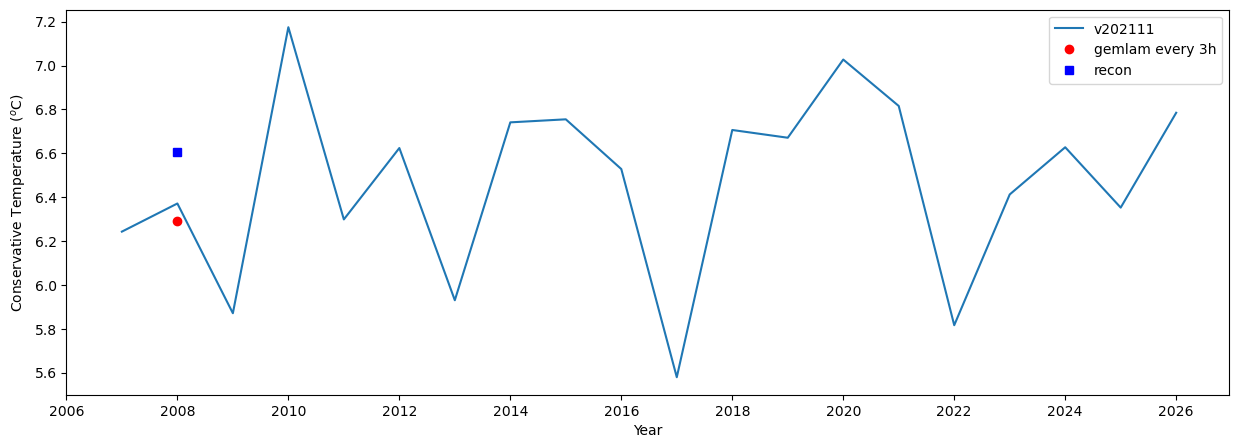

In [155]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
ax.plot(range(2007, 2027), mean_temp_v, label='v202111');
ax.plot([2008], mean_temp_3h, 'ro', label='gemlam every 3h')
ax.plot([2008], mean_temp_recon, 'bs', label='recon')
ax.set_xticks(range(2006, 2027, 2))
ax.set_xlabel('Year')
ax.set_ylabel('Conservative Temperature ($^o$C)')
ax.legend();

5.45507169262943
5.958479819852457


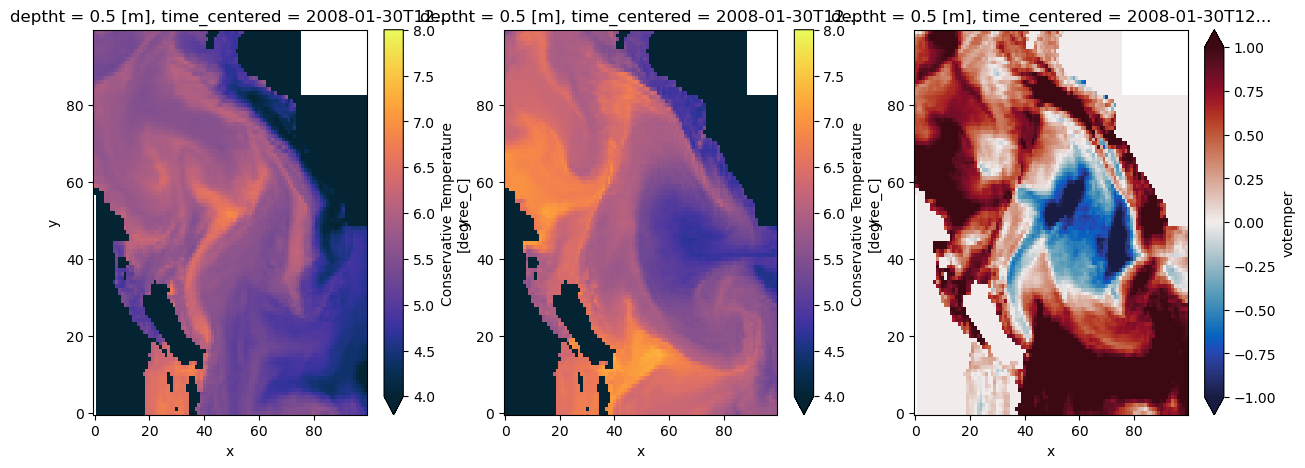

In [167]:
it, days = 12, 30-1
v202111 = xr.open_dataset(f'/results2/SalishSea/nowcast-green.202111/30jan08/SalishSea_1h_20080130_20080130_grid_T.nc')
recon = xr.open_dataset(f'/data/sallen/results/MEOPAR/DownScaleAtmos/Down/01jan08/SalishSea_1h_20080101_20080131_grid_T.nc')
triple_plot(it, days, v202111, recon, 'votemper', SoG_center, mesh, cm.thermal, 4, 8, 1)

### Sea Surface Temperature in the Puget Main ###

In [174]:
# January
mean_temp_v = np.zeros((20))
for iy, year in enumerate(range(2007, 2027, 1)):
    v202111 = xr.open_dataset(f'/results2/SalishSea/month-avg.202111/SalishSeaCast_1m_grid_T_{year}0101_{year}0131.nc')
    mean_temp_v[iy] = calculate_mean(v202111, mesh, PS_main, (0, 0), 'votemper')
    v202111.close()

In [176]:
v_3h = xr.open_dataset(f'/data/sallen/results/MEOPAR/DownScaleAtmos/Base/01jan08/SalishSea_1h_20080101_20080131_grid_T.nc')
mean_temp_3h = calculate_mean(v_3h, mesh, PS_main, (0, 0), 'votemper')
v_3h.close()

In [178]:
recon = xr.open_dataset(f'/data/sallen/results/MEOPAR/DownScaleAtmos/Down/01jan08/SalishSea_1h_20080101_20080131_grid_T.nc')
mean_temp_recon = calculate_mean(recon, mesh, PS_main, (0, 0), 'votemper')
recon.close()

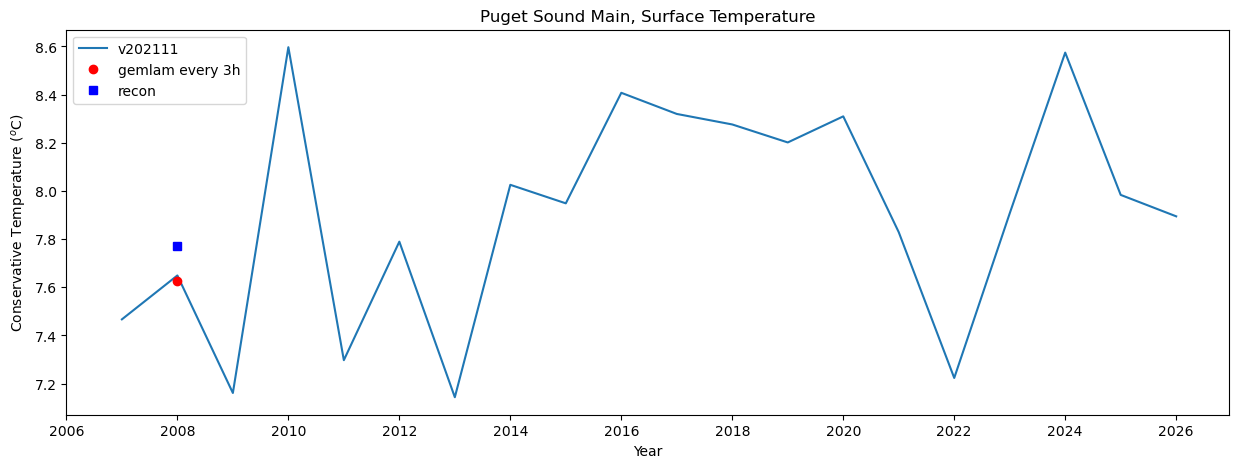

In [179]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
ax.plot(range(2007, 2027), mean_temp_v, label='v202111');
ax.plot([2008], mean_temp_3h, 'ro', label='gemlam every 3h')
ax.plot([2008], mean_temp_recon, 'bs', label='recon')
ax.set_xticks(range(2006, 2027, 2))
ax.set_xlabel('Year')
ax.set_ylabel('Conservative Temperature ($^o$C)')
ax.set_title('Puget Sound Main, Surface Temperature')
ax.legend();

7.540602311740207
7.751997094495723


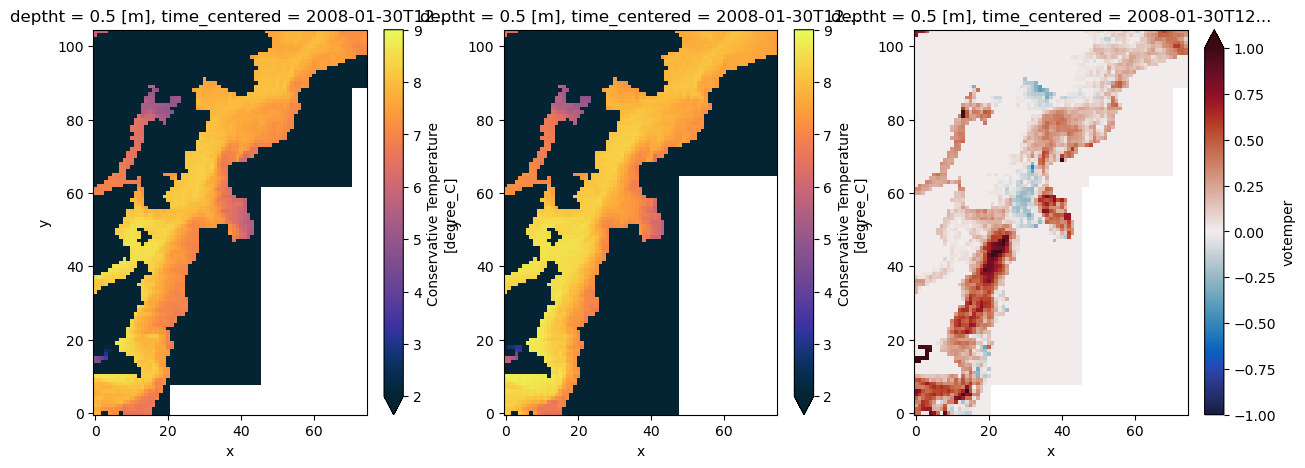

In [182]:
it, days = 12, 30-1
v202111 = xr.open_dataset(f'/results2/SalishSea/nowcast-green.202111/30jan08/SalishSea_1h_20080130_20080130_grid_T.nc')
recon = xr.open_dataset(f'/data/sallen/results/MEOPAR/DownScaleAtmos/Down/01jan08/SalishSea_1h_20080101_20080131_grid_T.nc')
triple_plot(it, days, v202111, recon, 'votemper', PS_main, mesh, cm.thermal, 2, 9, 1)

Temperature is a bit warmer at the surface.

### Deep Salinity in the Venus Region ###

In [68]:
# January
mean_salinity_v = np.zeros((20))
for iy, year in enumerate(range(2007, 2027, 1)):
    v202111 = xr.open_dataset(f'/results2/SalishSea/month-avg.202111/SalishSeaCast_1m_grid_T_{year}0101_{year}0131.nc')
    mean_salinity_v[iy] = calculate_mean(v202111, mesh, SoG_venus, 32, 'vosaline')
    v202111.close()

In [96]:
v_3h = xr.open_dataset(f'/data/sallen/results/MEOPAR/DownScaleAtmos/Base/01jan08/SalishSea_1h_20080101_20080131_grid_T.nc')
mean_salinity_3h = calculate_mean(v_3h, mesh, SoG_venus, (32, 32), 'vosaline')
v_3h.close()

In [162]:
#recon = xr.open_dataset(f'/data/sallen/results/MEOPAR/DownScaleAtmos/Down/01jan08/SalishSea_1h_20080101_20080131_grid_T.nc')
mean_salinity_recon = calculate_mean(recon, mesh, SoG_venus, (32, 32), 'vosaline')
recon.close()

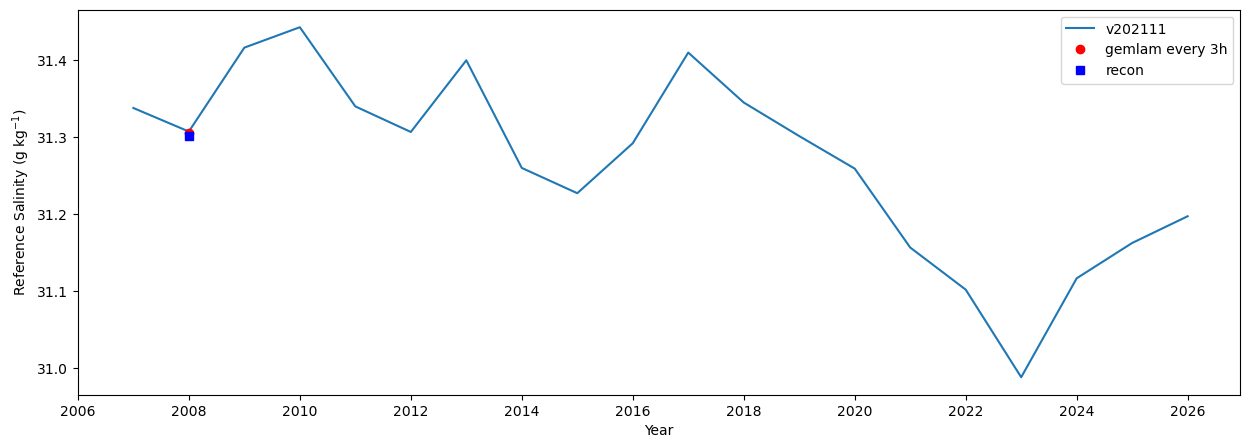

In [163]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
ax.plot(range(2007, 2027), mean_salinity_v, label='v202111');
ax.plot([2008], mean_salinity_3h, 'ro', label='gemlam every 3h')
ax.plot([2008], mean_salinity_recon, 'bs', label='recon')
ax.set_xticks(range(2006, 2027, 2))
ax.set_xlabel('Year')
ax.set_ylabel('Reference Salinity (g kg$^{-1}$)')
ax.legend();

First month! Salinity is good.

### Upper Layer Nitrate in the Northern SoG ###

In [79]:
# January
mean_nitrate_v = np.zeros((20))
for iy, year in enumerate(range(2007, 2027, 1)):
    v202111 = xr.open_dataset(f'/results2/SalishSea/month-avg.202111/SalishSeaCast_1m_biol_T_{year}0101_{year}0131.nc')
    mean_nitrate_v[iy] = calculate_mean(v202111, mesh, SoG_north, (0, 10), 'nitrate')
    v202111.close()

In [103]:
v_3h = xr.open_dataset(f'/data/sallen/results/MEOPAR/DownScaleAtmos/Base/01jan08/SalishSea_1h_20080101_20080131_biol_T.nc')
mean_nitrate_3h = calculate_mean(v_3h, mesh, SoG_north, (0, 10), 'nitrate')
v_3h.close()

In [186]:
recon = xr.open_dataset(f'/data/sallen/results/MEOPAR/DownScaleAtmos/Down/01jan08/SalishSea_1h_20080101_20080131_biol_T.nc')
mean_nitrate_recon = calculate_mean(recon, mesh, SoG_north, (0, 10), 'nitrate')
recon.close()

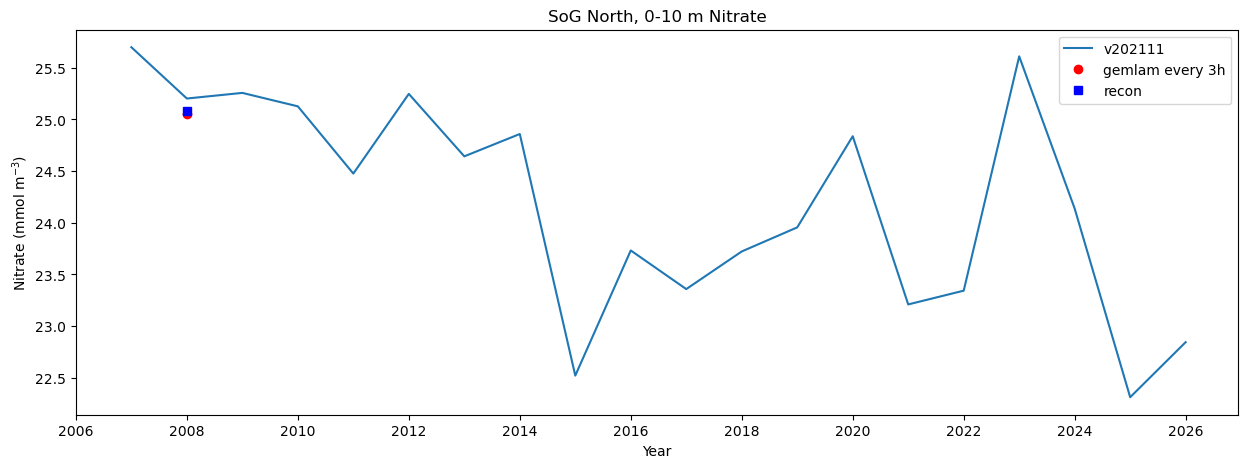

In [188]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
ax.plot(range(2007, 2027), mean_nitrate_v, label='v202111');
ax.plot([2008], mean_nitrate_3h, 'ro', label='gemlam every 3h')
ax.plot([2008], mean_nitrate_recon, 'bs', label='recon')
ax.set_xticks(range(2006, 2027, 2))
ax.set_xlabel('Year')
ax.set_ylabel('Nitrate (mmol m$^{-3}$)')
ax.set_title('SoG North, 0-10 m Nitrate')
ax.legend();

In [148]:
v202111 = xr.open_dataset(f'/results2/SalishSea/nowcast-green.202111/30jan08/SalishSea_1h_20080130_20080130_biol_T.nc')

In [119]:
var = 'nitrate'
v_3h = xr.open_dataset(f'/data/sallen/results/MEOPAR/DownScaleAtmos/Base/01jan08/SalishSea_1h_20080101_20080131_biol_T.nc')
v_3h_mean = v_3h[var][0, 0, SoG_north[0]:SoG_north[1], SoG_north[2]:SoG_north[3]]

24.500863502816628
23.93236906322844


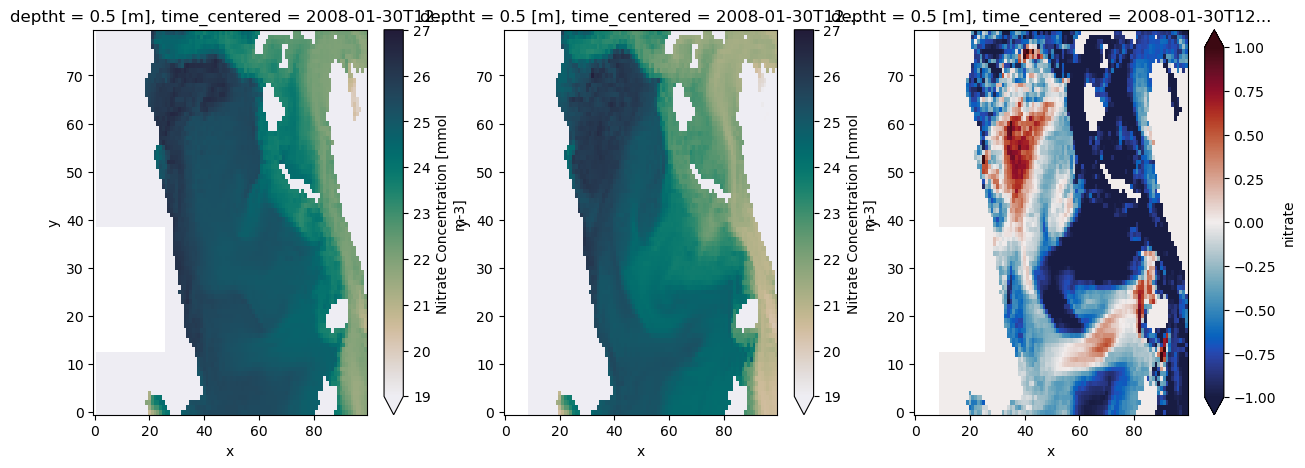

In [149]:
it, days = 12, 30-1
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
v202111[var][it, 0, SoG_north[0]:SoG_north[1], SoG_north[2]:SoG_north[3]].plot(ax=axs[0], cmap=cm.rain, vmin=19, vmax=27)
v_3h[var][it+days*24, 0, SoG_north[0]:SoG_north[1], SoG_north[2]:SoG_north[3]].plot(ax=axs[1], cmap=cm.rain, vmin=19, vmax=27)
(v_3h[var][it+days*24, 0, SoG_north[0]:SoG_north[1], SoG_north[2]:SoG_north[3]] - v202111[var][it, 0, SoG_north[0]:SoG_north[1], SoG_north[2]:SoG_north[3]]).plot(
    ax=axs[2], vmin=-1, vmax=1, cmap=cm.balance)
print (np.ma.masked_array(v202111[var][it, 0, SoG_north[0]:SoG_north[1], SoG_north[2]:SoG_north[3]],
                          mask=1-mesh.tmask[0, 0, SoG_north[0]:SoG_north[1], SoG_north[2]:SoG_north[3]]).mean())
print (np.ma.masked_array(v_3h[var][it+days*24, 0, SoG_north[0]:SoG_north[1], SoG_north[2]:SoG_north[3]],
                          mask=1-mesh.tmask[0, 0, SoG_north[0]:SoG_north[1], SoG_north[2]:SoG_north[3]]).mean())



### Diatoms in the NSoG ###

In [86]:
# January
mean_diatoms_v = np.zeros((20))
for iy, year in enumerate(range(2007, 2027, 1)):
    v202111 = xr.open_dataset(f'/results2/SalishSea/month-avg.202111/SalishSeaCast_1m_biol_T_{year}0101_{year}0131.nc')
    mean_diatoms_v[iy] = calculate_mean(v202111, mesh, SoG_north, (0, 10), 'diatoms')
    v202111.close()

In [150]:
v_3h = xr.open_dataset(f'/data/sallen/results/MEOPAR/DownScaleAtmos/Base/01jan08/SalishSea_1h_20080101_20080131_biol_T.nc')
mean_diatoms_3h = calculate_mean(v_3h, mesh, SoG_north, (0, 10), 'diatoms')
v_3h.close()

In [190]:
recon = xr.open_dataset(f'/data/sallen/results/MEOPAR/DownScaleAtmos/Down/01jan08/SalishSea_1h_20080101_20080131_biol_T.nc')
mean_diatoms_recon = calculate_mean(recon, mesh, SoG_north, (0, 10), 'diatoms')
recon.close()

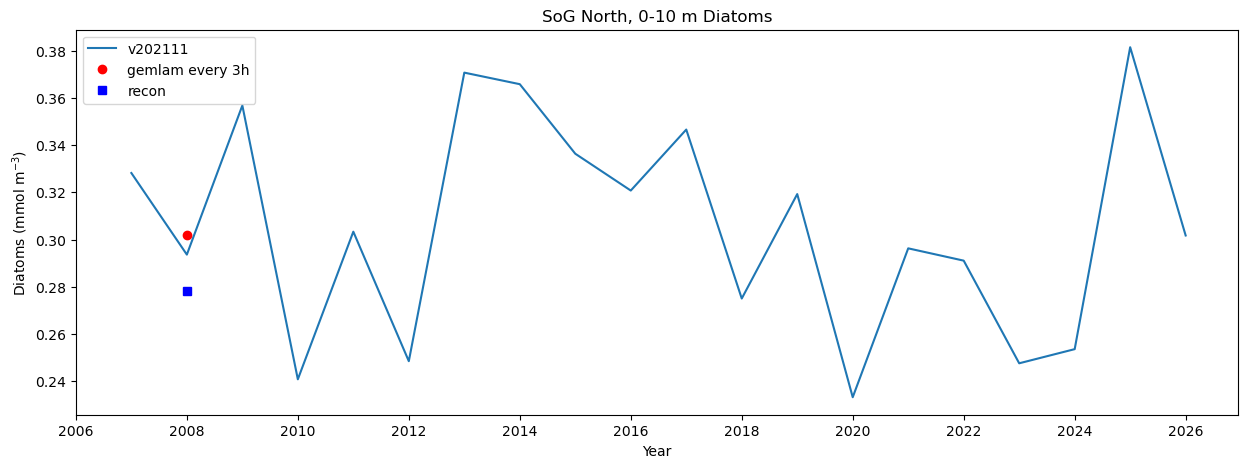

In [193]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
ax.plot(range(2007, 2027), mean_diatoms_v, label='v202111');
ax.plot([2008], mean_diatoms_3h, 'ro', label='gemlam every 3h')
ax.plot([2008], mean_diatoms_recon, 'bs', label='recon')
ax.set_xticks(range(2006, 2027, 2))
ax.set_xlabel('Year')
ax.set_ylabel('Diatoms (mmol m$^{-3}$)')
ax.set_title('SoG North, 0-10 m Diatoms')
ax.legend();

### Nanoflagellates in the north Central SoG ###

Based on the problems with Central SoG for temperature, I'm going to use a smaller Central Box.

In [198]:
# January
mean_flag_v = np.zeros((20))
for iy, year in enumerate(range(2007, 2027, 1)):
    v202111 = xr.open_dataset(f'/results2/SalishSea/month-avg.202111/SalishSeaCast_1m_biol_T_{year}0101_{year}0131.nc')
    mean_flag_v[iy] = calculate_mean(v202111, mesh, SoG_ncenter, (0, 10), 'flagellates')
    v202111.close()

In [201]:
v_3h = xr.open_dataset(f'/data/sallen/results/MEOPAR/DownScaleAtmos/Base/01jan08/SalishSea_1h_20080101_20080131_biol_T.nc')
mean_flag_3h = calculate_mean(v_3h, mesh, SoG_ncenter, (0, 10), 'flagellates')
v_3h.close()

In [205]:
recon = xr.open_dataset(f'/data/sallen/results/MEOPAR/DownScaleAtmos/Down/01jan08/SalishSea_1h_20080101_20080131_biol_T.nc')
mean_flag_recon = calculate_mean(recon, mesh, SoG_ncenter, (0, 10), 'flagellates')
recon.close()

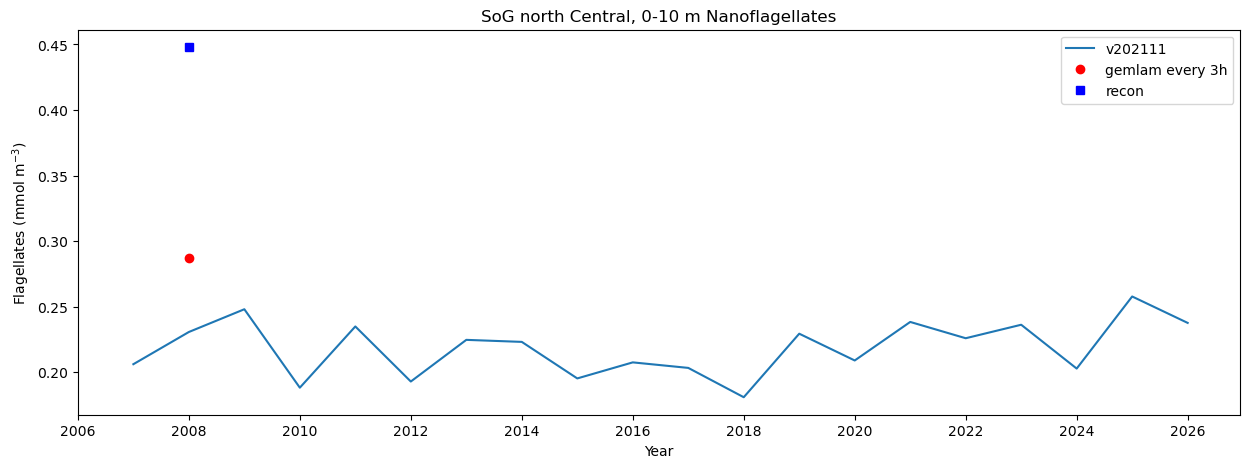

In [207]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
ax.plot(range(2007, 2027), mean_flag_v, label='v202111');
ax.plot([2008], mean_flag_3h, 'ro', label='gemlam every 3h')
ax.plot([2008], mean_flag_recon, 'bs', label='recon')
ax.set_xticks(range(2006, 2027, 2))
ax.set_xlabel('Year')
ax.set_ylabel('Flagellates (mmol m$^{-3}$)')
ax.set_title('SoG north Central, 0-10 m Nanoflagellates')
ax.legend();

### Compare Atmospheric Forcing ###

In [8]:
atmos_3h = xr.open_dataset('/data/sallen/results/MEOPAR/DownScaleAtmos/Base/01jan08/SalishSea_1h_20080101_20080131_sbfx_T.nc')

In [9]:
atmos_recon = xr.open_dataset('/data/sallen/results/MEOPAR/DownScaleAtmos/Down/01jan08/SalishSea_1h_20080101_20080131_sbfx_T.nc')

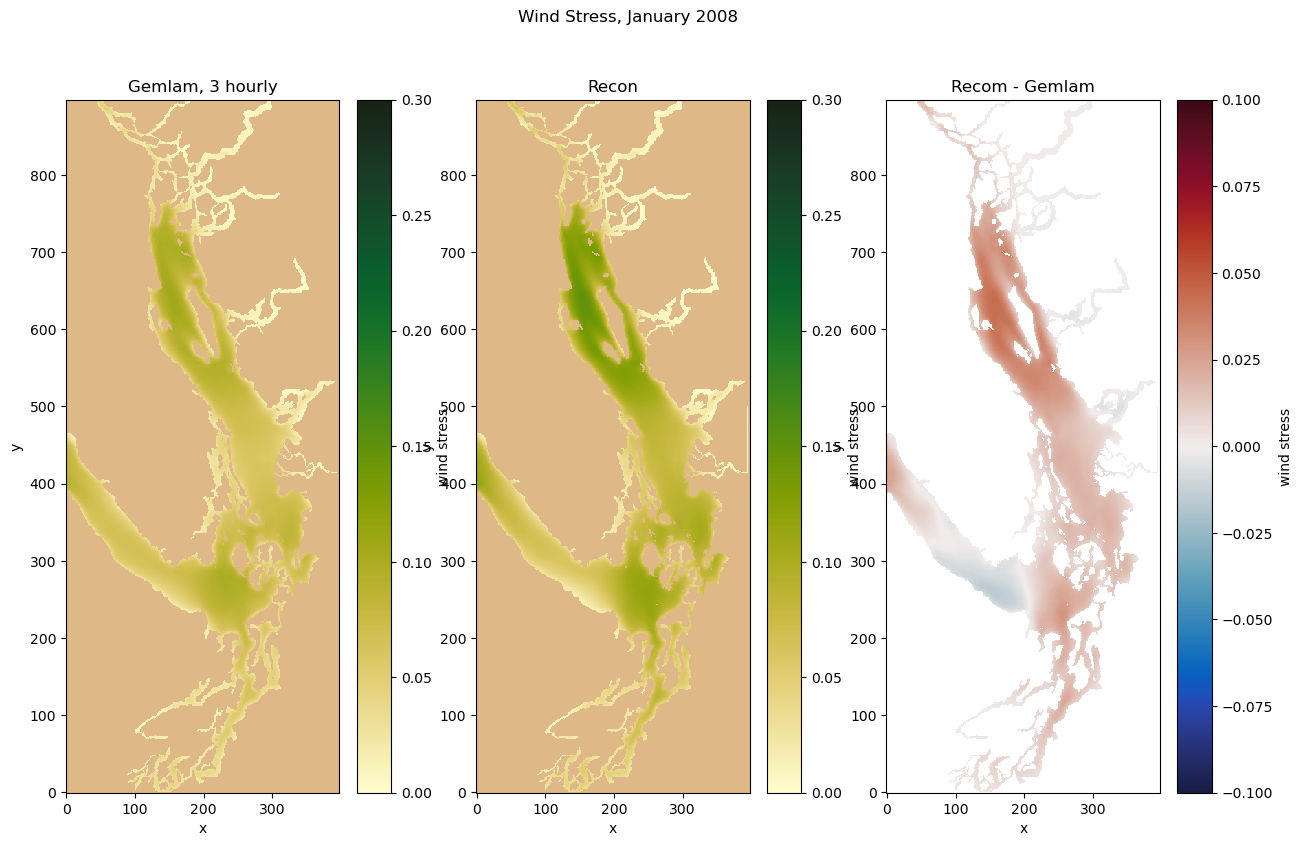

In [26]:
fig, axs = triple_plot_mean(atmos_3h, atmos_recon, 'wind stress', cm.speed, 0, 0.3, 0.1)
fig.suptitle('Wind Stress, January 2008')
axs[0].set_title('Gemlam, 3 hourly')
axs[1].set_title('Recon')
axs[2].set_title ('Recom - Gemlam');

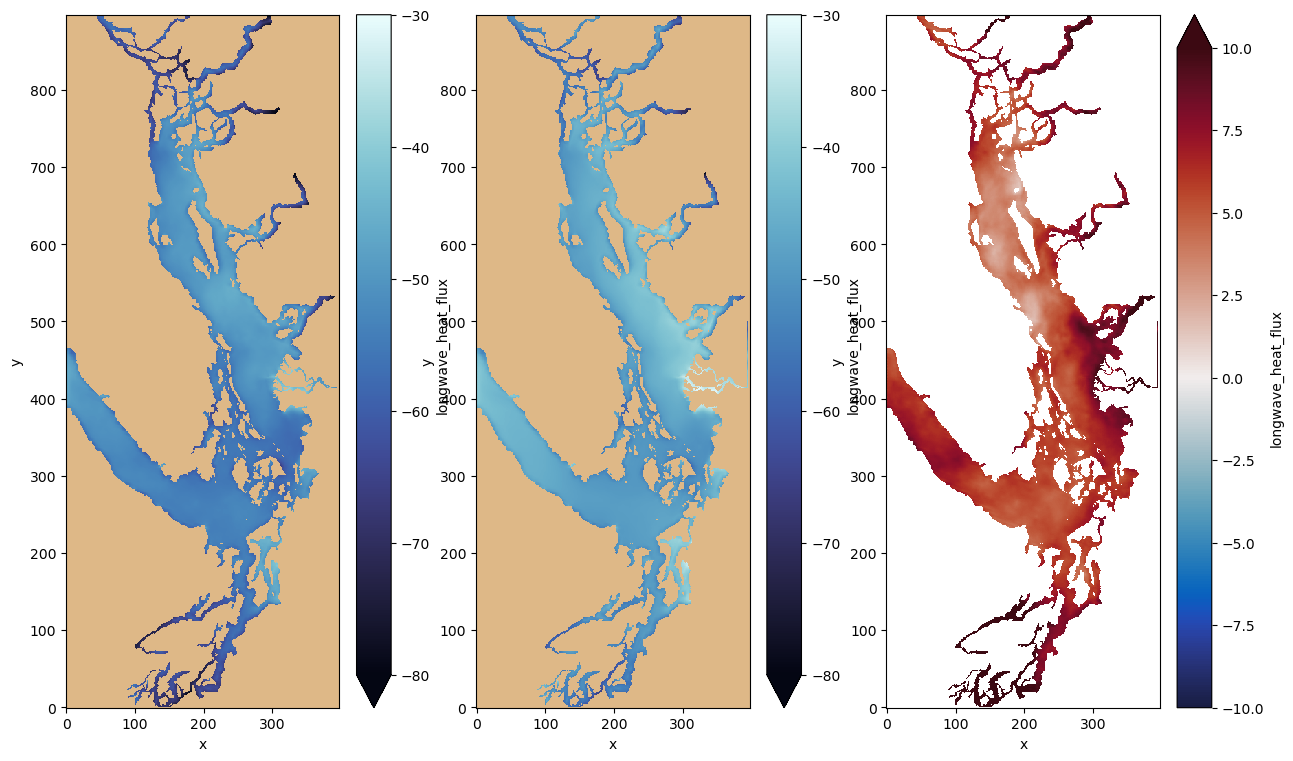

In [246]:
triple_plot_mean(atmos_3h, atmos_recon, 'longwave_heat_flux', cm.ice, -80, -30, 10, nomask=False)

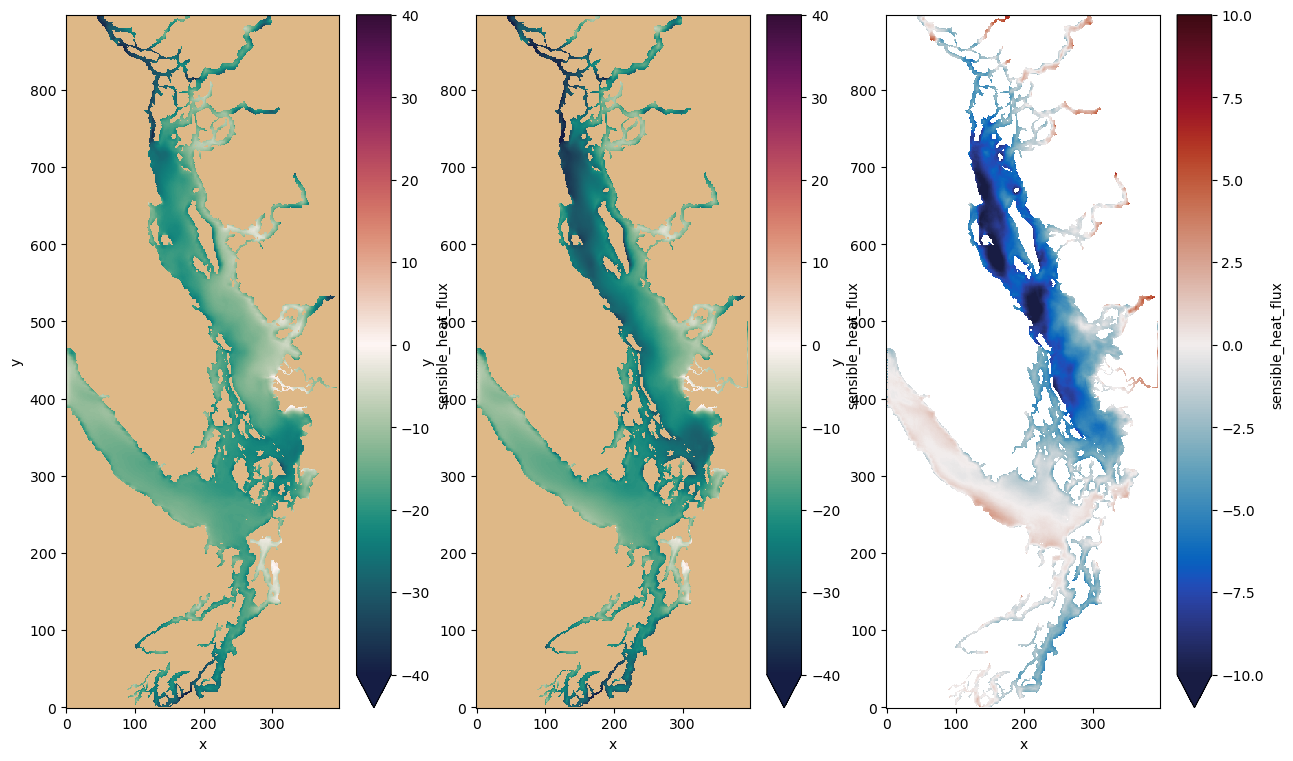

In [248]:
triple_plot_mean(atmos_3h, atmos_recon, 'sensible_heat_flux', cm.curl, -40, 40, 10, nomask=False)

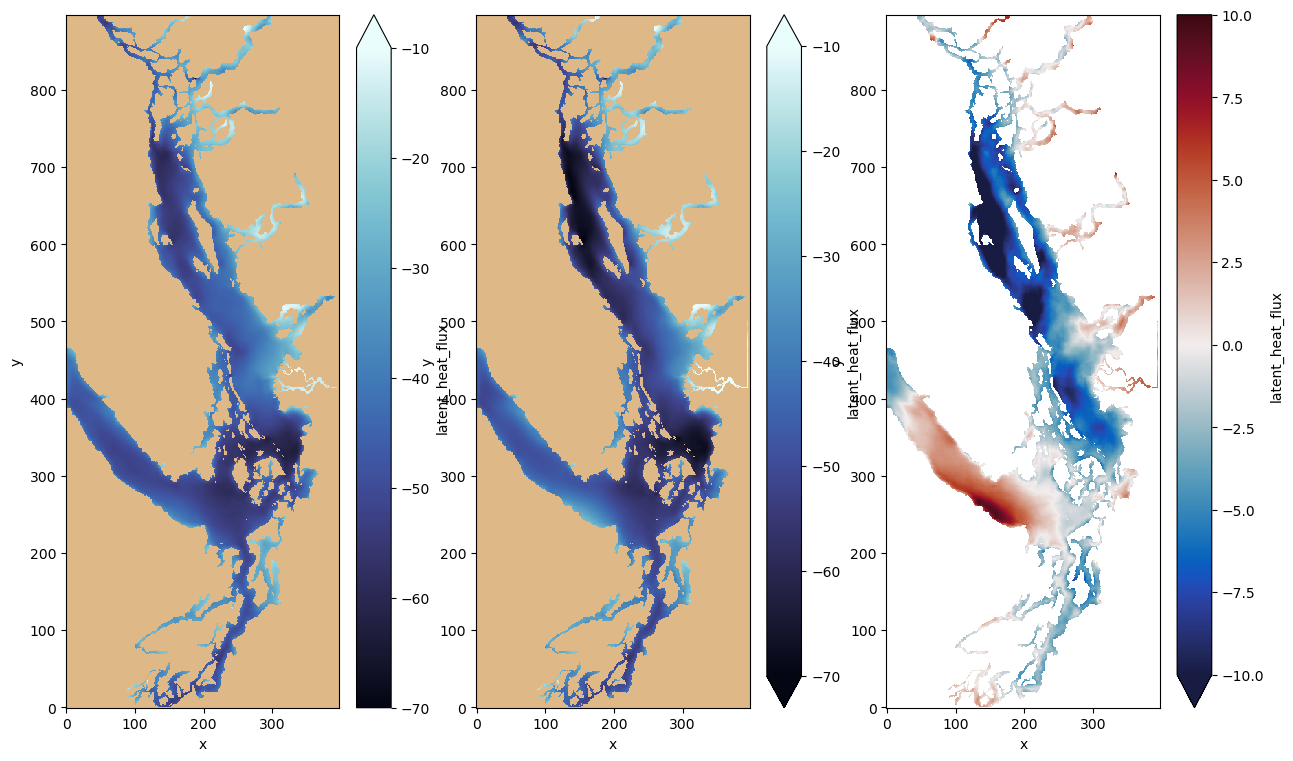

In [250]:
triple_plot_mean(atmos_3h, atmos_recon, 'latent_heat_flux', cm.ice, -70, -10, 10, nomask=False)

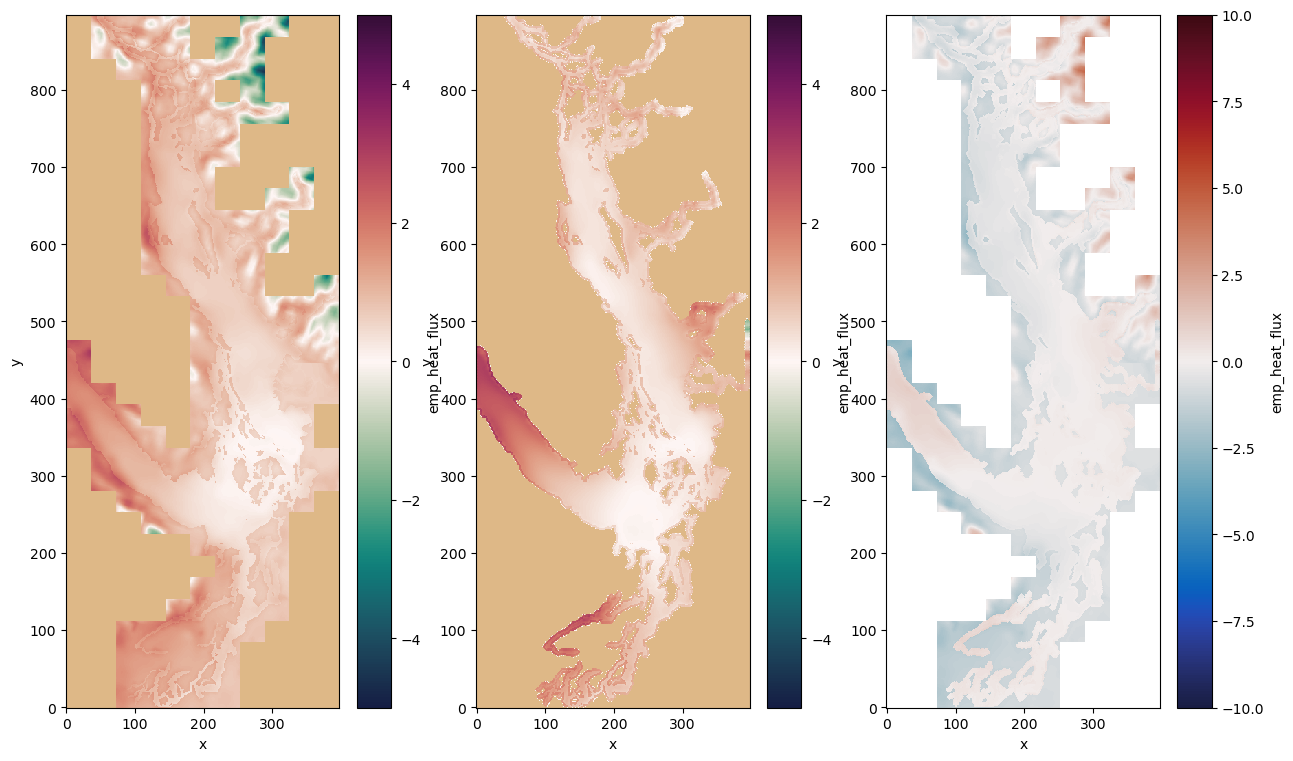

In [12]:
triple_plot_mean(atmos_3h, atmos_recon, 'emp_heat_flux', cm.curl, -5, 5, 10, nomask=False)

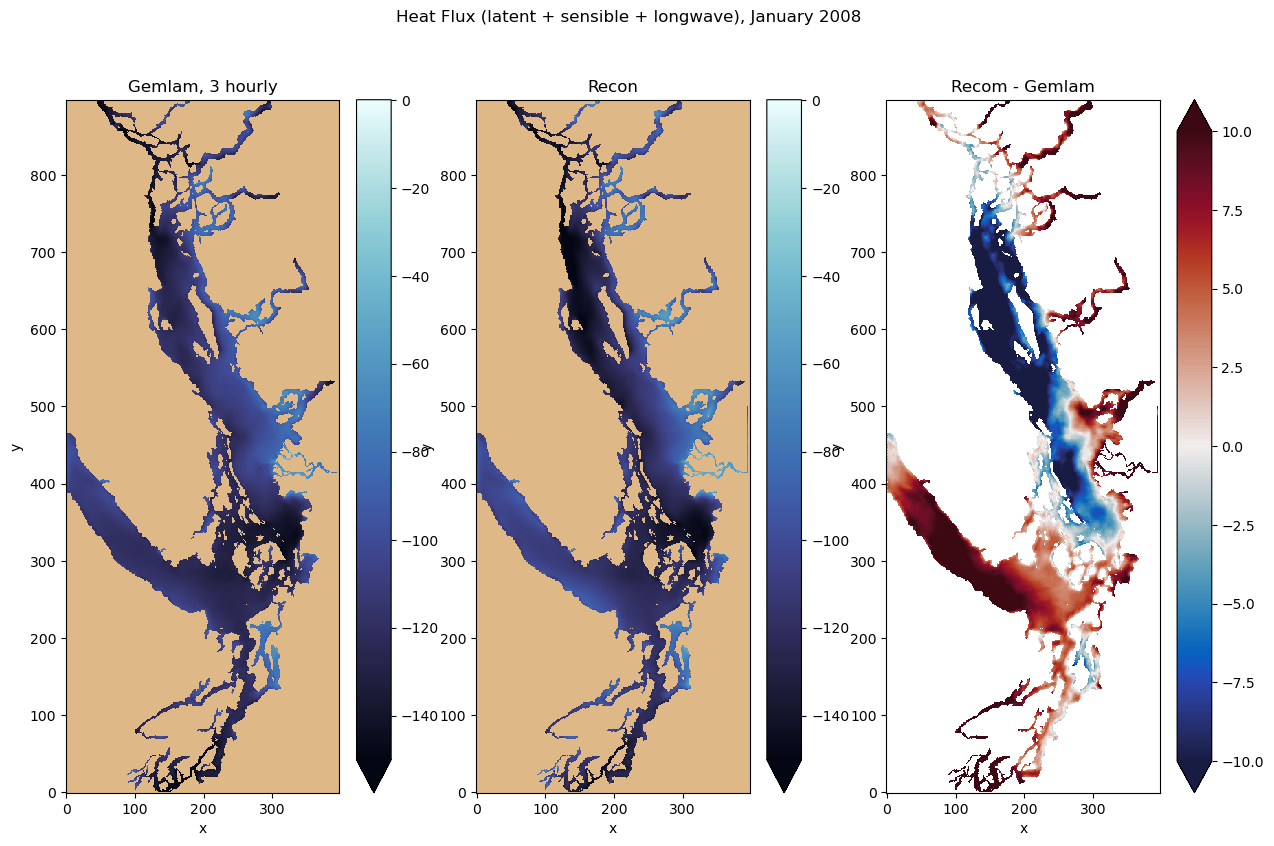

In [23]:
cmap = cm.ice
mapA = copy.copy(cmap)
vmin = -150
vmax = 0
dv = 10
mymap = mapA.with_extremes(bad='burlywood')
fig, axs = plt.subplots(1, 3, figsize=(15, 9))
v3hmean = (atmos_3h['longwave_heat_flux']+atmos_3h['sensible_heat_flux']+atmos_3h['latent_heat_flux']+0*atmos_3h['emp_heat_flux']).mean(axis=0)
reconmean = (atmos_recon['longwave_heat_flux']+atmos_recon['sensible_heat_flux']+atmos_recon['latent_heat_flux']+0*atmos_recon['emp_heat_flux']).mean(axis=0)

v3hmean.where(v3hmean != 0).plot(ax=axs[0], cmap=mymap, vmin=vmin, vmax=vmax)
reconmean.where(reconmean != 0).plot(ax=axs[1], cmap=mymap, vmin=vmin, vmax=vmax)
(reconmean - v3hmean).where(reconmean - v3hmean != 0).plot(
 ax=axs[2], vmin=-dv, vmax=dv, cmap=cm.balance)
fig.suptitle('Heat Flux (latent + sensible + longwave), January 2008')
axs[0].set_title('Gemlam, 3 hourly')
axs[1].set_title('Recon')
axs[2].set_title ('Recom - Gemlam');

### 